In [1]:
print("Customer Segmentation Analysis")
print("Jupyter is working successfully!")

Customer Segmentation Analysis
Jupyter is working successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_excel("Online Retail.xlsx")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Check column names
print("Column Names:")
print(df.columns.tolist())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate records
print("\nDuplicate Records:")
print(df.duplicated().sum())

# Check data types
print("\nData Types:")
print(df.dtypes)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Records:
5268

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


In [5]:

# Step 12: Data Cleaning

# Make a copy of the original dataset
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove rows where CustomerID is missing
df_clean = df_clean.dropna(subset=["CustomerID"])

# Remove rows where Description is missing
df_clean = df_clean.dropna(subset=["Description"])

# Convert CustomerID to integer
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

# Ensure InvoiceDate has the correct datetime format
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Remove cancelled invoices (invoice numbers starting with C)
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

# Keep only positive quantities and prices
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
].copy()

# Calculate total purchase amount
df_clean["TotalAmount"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

# Display cleaning results
print("DATA CLEANING COMPLETED!")
print("-" * 40)

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

print("\nCleaned dataset preview:")
display(df_clean.head())

DATA CLEANING COMPLETED!
----------------------------------------
Original rows: 541909
Cleaned rows: 392692
Rows removed: 149217

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

Cleaned dataset preview:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [6]:

# Step 13: RFM Analysis
# RFM = Recency, Frequency, Monetary

# Reference date: one day after the last transaction
reference_date = (
    df_clean["InvoiceDate"].max().normalize()
    + pd.Timedelta(days=1)
)

# Calculate RFM for every customer
rfm = df_clean.groupby("CustomerID").agg(
    Recency=(
        "InvoiceDate",
        lambda dates: (
            reference_date - dates.max().normalize()
        ).days
    ),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

# Display results
print("RFM ANALYSIS COMPLETED!")
print("-" * 40)

print("Total unique customers:", len(rfm))

print("\nFirst 10 customer RFM records:")
display(rfm.head(10))

print("\nRFM descriptive statistics:")
display(rfm[["Recency", "Frequency", "Monetary"]].describe().round(2))

RFM ANALYSIS COMPLETED!
----------------------------------------
Total unique customers: 4338

First 10 customer RFM records:


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,3,7,4310.00
2,12348,76,4,1797.24
3,12349,19,1,1757.55
4,12350,311,1,334.40
5,12352,37,8,2506.04
6,12353,205,1,89.00
7,12354,233,1,1079.40
8,12355,215,1,459.40
9,12356,23,3,2811.43



RFM descriptive statistics:


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,93.06,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.75,5.00,1660.60
max,374.00,209.00,280206.02


In [7]:

# Step 14: Customer Purchase Statistics

total_customers = rfm["CustomerID"].nunique()
total_orders = rfm["Frequency"].sum()
total_revenue = rfm["Monetary"].sum()

print("CUSTOMER PURCHASE STATISTICS")
print("-" * 40)

print("Total customers:", total_customers)
print("Total distinct customer invoices:", total_orders)
print("Total historical revenue: £", round(total_revenue, 2))

print(
    "Average invoices per customer:",
    round(rfm["Frequency"].mean(), 2)
)

print(
    "Average historical spending per customer: £",
    round(rfm["Monetary"].mean(), 2)
)

print(
    "Average purchase value per invoice: £",
    round(total_revenue / total_orders, 2)
)

CUSTOMER PURCHASE STATISTICS
----------------------------------------
Total customers: 4338
Total distinct customer invoices: 18532
Total historical revenue: £ 8887208.89
Average invoices per customer: 4.27
Average historical spending per customer: £ 2048.69
Average purchase value per invoice: £ 479.56


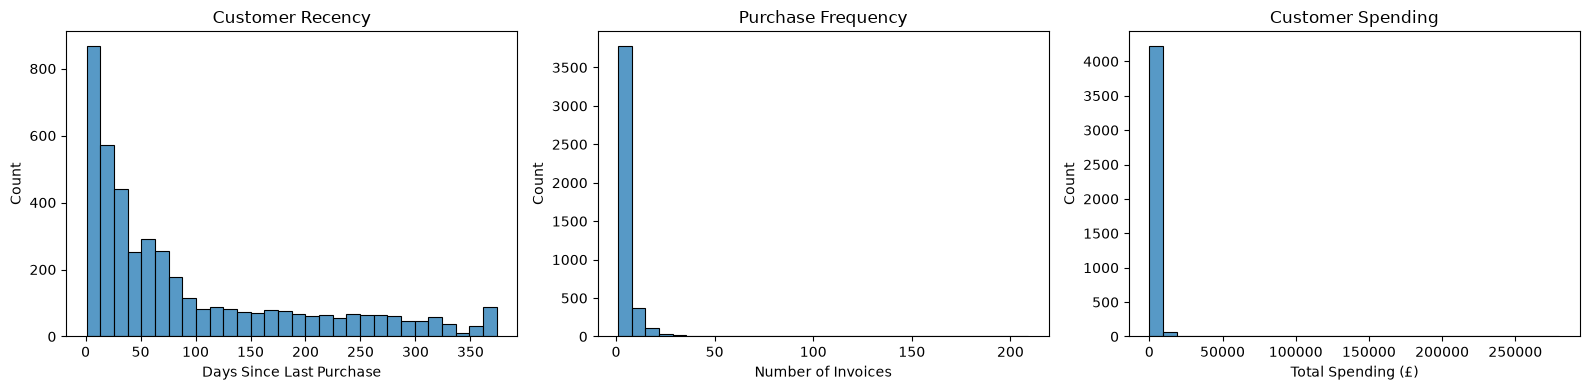

In [8]:

# Step 15: RFM Distribution Charts

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=rfm, x="Recency", bins=30, ax=axes[0])
axes[0].set_title("Customer Recency")
axes[0].set_xlabel("Days Since Last Purchase")

sns.histplot(data=rfm, x="Frequency", bins=30, ax=axes[1])
axes[1].set_title("Purchase Frequency")
axes[1].set_xlabel("Number of Invoices")

sns.histplot(data=rfm, x="Monetary", bins=30, ax=axes[2])
axes[2].set_title("Customer Spending")
axes[2].set_xlabel("Total Spending (£)")

plt.tight_layout()
plt.show()

In [9]:

# Step 16: Feature Preparation and Standardisation

# Select the three behavioural features
features = ["Recency", "Frequency", "Monetary"]

X = rfm[features].copy()

# Reduce the effect of extremely large values
X = np.log1p(X)

# Standardise the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardisation completed successfully!")
print("Original feature shape:", X.shape)
print("Scaled feature shape:", X_scaled.shape)

# Display a preview of the scaled values
display(
    pd.DataFrame(X_scaled, columns=features).head()
)

Standardisation completed successfully!
Original feature shape: (4338, 3)
Scaled feature shape: (4338, 3)


,Recency,Frequency,Monetary
0,1.478884,-0.955214,3.707716
1,-1.890642,1.074425,1.414903
2,0.372339,0.386304,0.720024
3,-0.659158,-0.955214,0.702287
4,1.442954,-0.955214,-0.614514


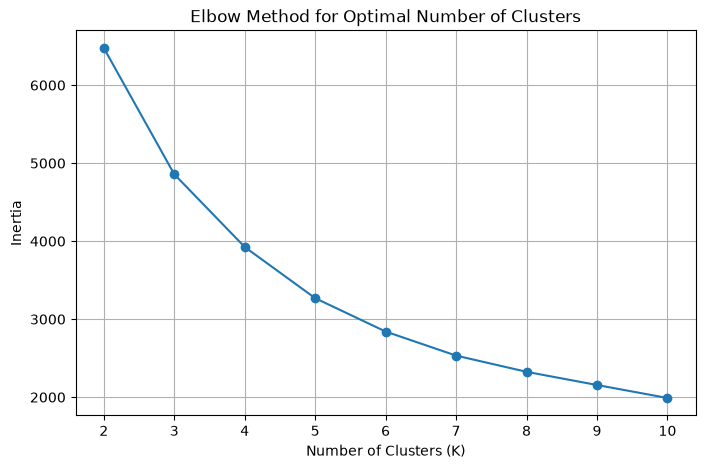

In [10]:

# Step 17: Elbow Method

inertia_values = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

In [11]:

# Step 19: Apply K-Means Clustering

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Assign a cluster number to every customer
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

# Evaluate clustering quality
score = silhouette_score(X_scaled, rfm["Cluster"])

print("K-MEANS CLUSTERING COMPLETED!")
print("--------------------------------")
print("Number of clusters:", optimal_k)
print("Silhouette Score:", round(score, 3))

print("\nFirst 10 segmented customers:")
display(rfm.head(10))

K-MEANS CLUSTERING COMPLETED!
--------------------------------
Number of clusters: 4
Silhouette Score: 0.333

First 10 segmented customers:


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,1
1,12347,3,7,4310.00,3
2,12348,76,4,1797.24,1
3,12349,19,1,1757.55,0
4,12350,311,1,334.40,2
5,12352,37,8,2506.04,1
6,12353,205,1,89.00,2
7,12354,233,1,1079.40,2
8,12355,215,1,459.40,2
9,12356,23,3,2811.43,1


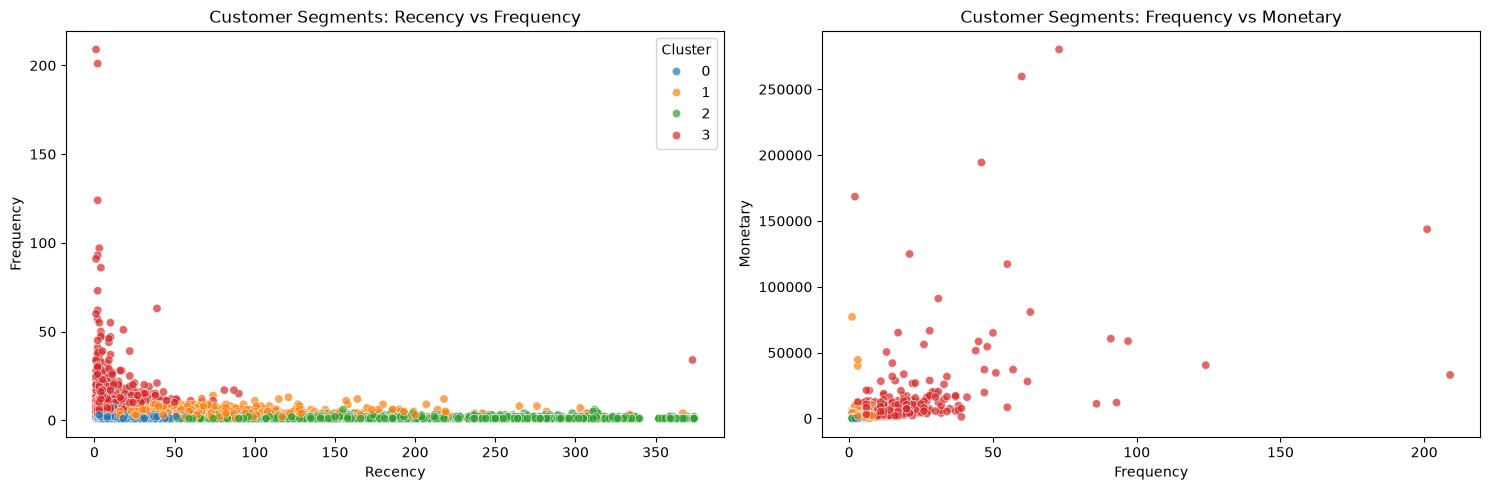

In [12]:

# Step 20: Visualise Customer Clusters

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Graph 1: Recency vs Frequency
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="tab10",
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title("Customer Segments: Recency vs Frequency")

# Graph 2: Frequency vs Monetary
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="tab10",
    alpha=0.7,
    ax=axes[1],
    legend=False
)

axes[1].set_title("Customer Segments: Frequency vs Monetary")

plt.tight_layout()
plt.show()

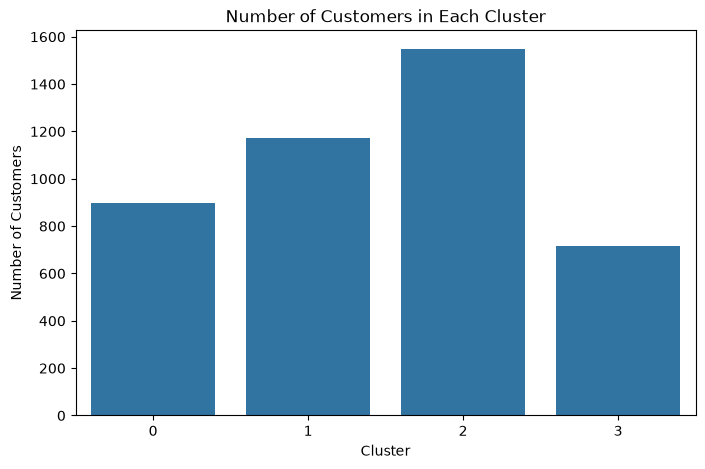

Customers in each cluster:
Cluster
0     897
1    1174
2    1549
3     718
Name: count, dtype: int64


In [13]:

# Step 21: Customer Count per Cluster

cluster_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index.astype(str),
    y=cluster_counts.values
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

print("Customers in each cluster:")
print(cluster_counts)

In [14]:

# Step 22: Customer Cluster Profiling

cluster_profile = rfm.groupby("Cluster").agg(
    Customer_Count=("CustomerID", "count"),
    Average_Recency=("Recency", "mean"),
    Average_Frequency=("Frequency", "mean"),
    Average_Monetary=("Monetary", "mean"),
    Median_Monetary=("Monetary", "median")
).round(2)

print("CUSTOMER CLUSTER PROFILE")
display(cluster_profile)

CUSTOMER CLUSTER PROFILE


,Customer_Count,Average_Recency,Average_Frequency,Average_Monetary,Median_Monetary
Cluster,,,,,
0,897,22.79,1.92,486.06,414.20
1,1174,65.29,4.19,1822.98,1355.04
2,1549,192.27,1.35,360.55,303.16
3,718,12.21,13.64,8011.89,3687.77


In [15]:

# Step 23: Marketing Recommendations

median_recency = cluster_profile["Average_Recency"].median()
median_frequency = cluster_profile["Average_Frequency"].median()
median_monetary = cluster_profile["Average_Monetary"].median()

def marketing_recommendation(row):
    recency = row["Average_Recency"]
    frequency = row["Average_Frequency"]
    monetary = row["Average_Monetary"]

    if (
        recency <= median_recency
        and frequency >= median_frequency
        and monetary >= median_monetary
    ):
        return "Loyal / High Value: Rewards, VIP offers, early access"

    elif (
        recency > median_recency
        and monetary >= median_monetary
    ):
        return "At Risk: Win-back offers and personalised reminders"

    elif recency <= median_recency:
        return "Active / Recent: Product recommendations and second-purchase offers"

    else:
        return "Low Engagement: Affordable promotions and reactivation campaigns"

cluster_profile["Marketing_Recommendation"] = (
    cluster_profile.apply(marketing_recommendation, axis=1)
)

print("CUSTOMER SEGMENTS AND MARKETING STRATEGIES")
display(cluster_profile)

CUSTOMER SEGMENTS AND MARKETING STRATEGIES


,Customer_Count,Average_Recency,Average_Frequency,Average_Monetary,Median_Monetary,Marketing_Recommendation
Cluster,,,,,,
0,897,22.79,1.92,486.06,414.20,Active / Recent: Product recommendations and s...
1,1174,65.29,4.19,1822.98,1355.04,At Risk: Win-back offers and personalised remi...
2,1549,192.27,1.35,360.55,303.16,Low Engagement: Affordable promotions and reac...
3,718,12.21,13.64,8011.89,3687.77,"Loyal / High Value: Rewards, VIP offers, early..."


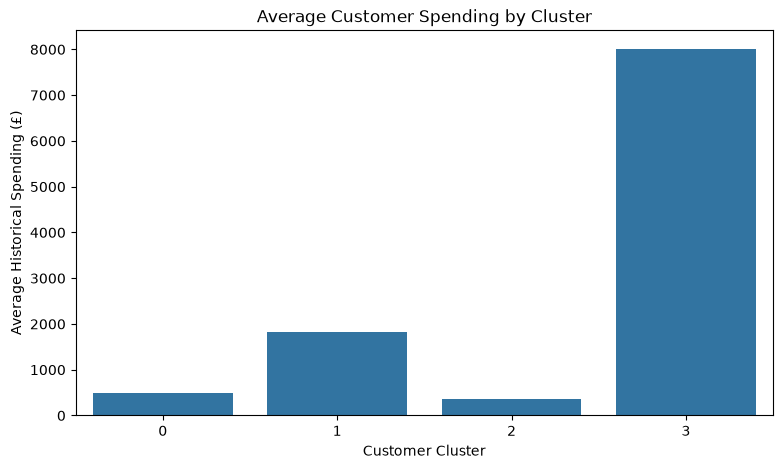

In [16]:

# Step 24: Compare Average Spending by Cluster

plt.figure(figsize=(9, 5))

sns.barplot(
    x=cluster_profile.index.astype(str),
    y=cluster_profile["Average_Monetary"]
)

plt.title("Average Customer Spending by Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Average Historical Spending (£)")
plt.show()

In [17]:

# Step 25: Export Project Results

import os

os.makedirs("outputs", exist_ok=True)

rfm.to_csv("outputs/customer_segments.csv", index=False)

cluster_profile.to_csv(
    "outputs/cluster_profiles.csv",
    index=True
)

print("PROJECT RESULTS SAVED SUCCESSFULLY!")
print("Files created:")
print("1. outputs/customer_segments.csv")
print("2. outputs/cluster_profiles.csv")

PROJECT RESULTS SAVED SUCCESSFULLY!
Files created:
1. outputs/customer_segments.csv
2. outputs/cluster_profiles.csv


# Conclusion

Customer Segmentation Analysis was performed using the Online Retail dataset. The dataset was inspected and cleaned to handle missing values, duplicate records, cancelled invoices, and invalid transactions.

RFM analysis was used to calculate Recency, Frequency, and Monetary values for each customer. These behavioural features were transformed and standardised before applying the K-Means clustering algorithm.

The Elbow Method was used to help select a suitable number of clusters. Customer segments were visualised using scatter plots, and a bar chart was created to compare the number of customers in each segment.

The cluster profiles helped identify differences in purchasing behaviour. Based on these differences, targeted marketing recommendations were proposed, including loyalty rewards, personalised promotions, and reactivation campaigns.

This project demonstrates how data analysis and machine learning can help an e-commerce business understand customer behaviour and plan more targeted marketing strategies.
